 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : Tomas Wynne                <br>
Student Number : L00196526                  <br>
Due Date       : 12th May 2026              <br>
Assignment     : CA2                        <br>
Module         : AI for Vision and NLP      <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [8]:
# pip installs via requirements.txt
# python -m spacy download en_core_web_sm
# pip install spacy


## Imports

In [9]:
# imports

#import sys
#print(sys.executable)

#import os
#import site
#print(site.getusersitepackages())
import cv2
#import pymupdf

import numpy as np
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt
# allows inline plotting
%matplotlib inline
# Setting global params for matplotlib
plt.rcParams['figure.figsize'] = (20, 20)

import pytesseract
from pytesseract import Output
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# regular expression
import re

# Load NLP model
nlp = spacy.load("en_core_web_sm")

# Support Functions

In [ ]:
# code here

def load_image(path):
    image = cv2.imread(path)
    if image is None:
        raise ValueError("Image not found. Check file path.")
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image, image_rgb

def preprocess_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)[1]
    return gray, thresh

 # Makes a token out of the lemma of every word in the document that is not a stop word, punctuation or a space
def preprocess_text(text):
    document = nlp(text)
    tokens = []

    for token in document:
        if not token.is_stop and not token.is_punct and not token.is_space:
            tokens.append(token.lemma_.lower())
    return tokens, document

# Returns Named Entities
def get_entities(doc):
    entities = []
    for ent in doc.ents:
        entities.append((ent.text, ent.label_))
    return entities

def get_tfidf(text):
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform([text])
    feature_names = vectorizer.get_feature_names_out()
    scores = tfidf_matrix.toarray()[0]
    return list(zip(feature_names, scores))

# NLP

## Sub Heading 1

Introduction

There have been periods of violence in the Northern part of the island for many
years, both before and after partition in 1920. The people of the North, and to
a lesser extent, of the South and of Britain have, during these periods, suffered
death, maiming and bombing. The violence has destroyed jobs and economic
Opportunities. But the most sustained and atrocious period of violence has been
that of the past 14 years since 1969. This paper outlines the terrible effects of
that violence and estimates its costs in human and economic terms for the people
of Ireland, North and South, and for the people of Britain.

The sources for the various tables in this study are listed in Appendix II.
References to figures "at current prices" relate, in the case of a single figure,
to the money values of that year and, in the case of a period of years, to the

money values of each succeeding year in the period in question.

Deaths and Injuries in the North

- The most tragic cost of viol

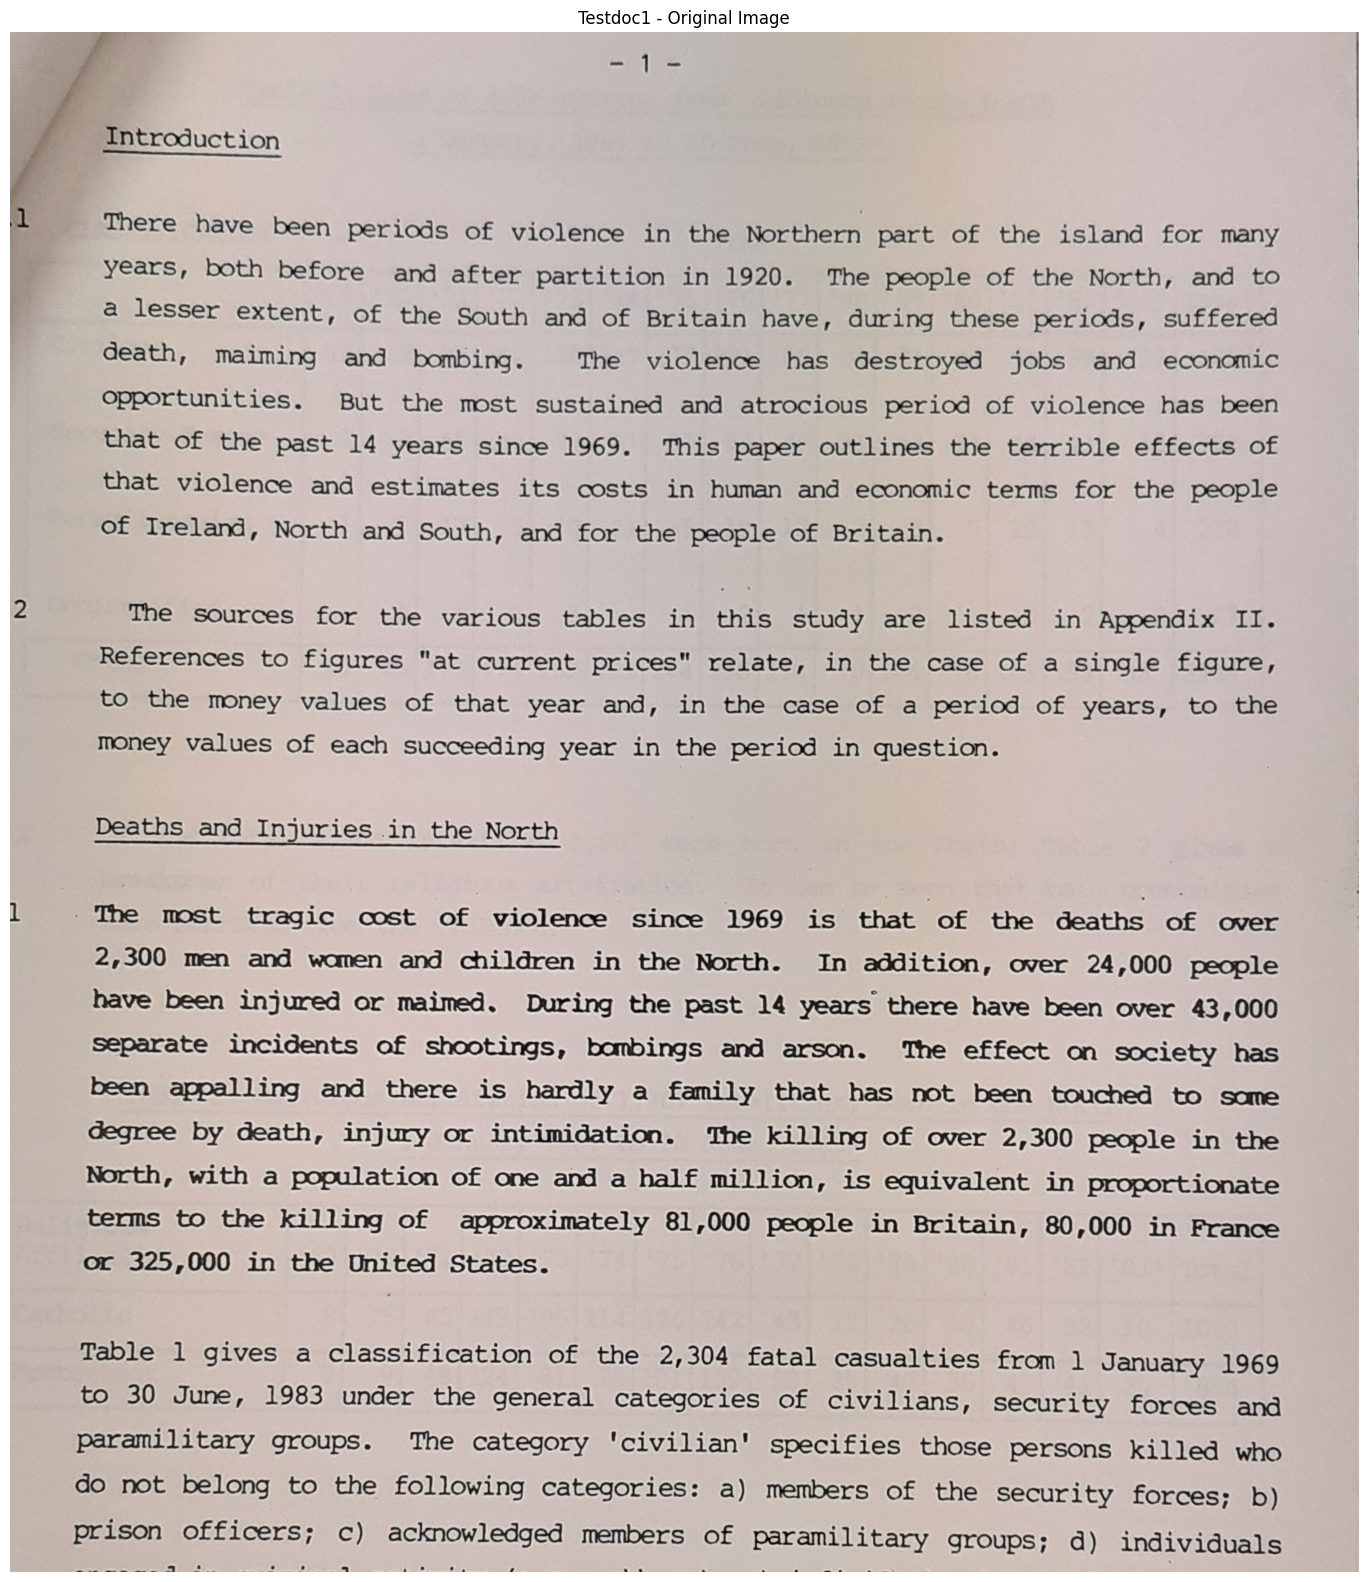

In [11]:
## code

# Take in first image
image, image_rgb = load_image("Testdoc1.jpg")

# Display image
plt.imshow(image_rgb)
plt.title("Testdoc1 - Original Image")
plt.axis("off")

# Display Raw Text, added preprocessing to make it cleaner
#text = pytesseract.image_to_string(image)
#print(text)

# Preprocess the image (greyscale and binary thresh)
gray, thresh = preprocess_image(image)

# Display processed text
text = pytesseract.image_to_string(thresh)
print(text)

# Process the text, returns clean tokens and document object of text
tokens, document = preprocess_text(text)

print("\n--- First 50 Tokens ---\n")
print(tokens[:50])

# Returns named entities from the document
entities = get_entities(document)
print("\n--- Named Entities ---\n")
for text, label in entities:
    print(f"{text}: {label}")

# Returns weighted tokens which are sorted to display the most important tokens.
clean_text = " ".join(tokens)
features = get_tfidf(clean_text)
top_features = sorted(features, key=lambda x: x[1], reverse=True)[:15]

print("\n--- Top TF-IDF Features ---\n")
for word, score in top_features:
    print(f"{word}: {score:.4f}")

# Vision

## Sub Heading 1

In [12]:
# code here...

# Multi-modal

## Sub Heading 1

In [13]:
# code here

# Final Output

In [14]:
# code